In [1]:
import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm, awgn
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise, gaussianComplexNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

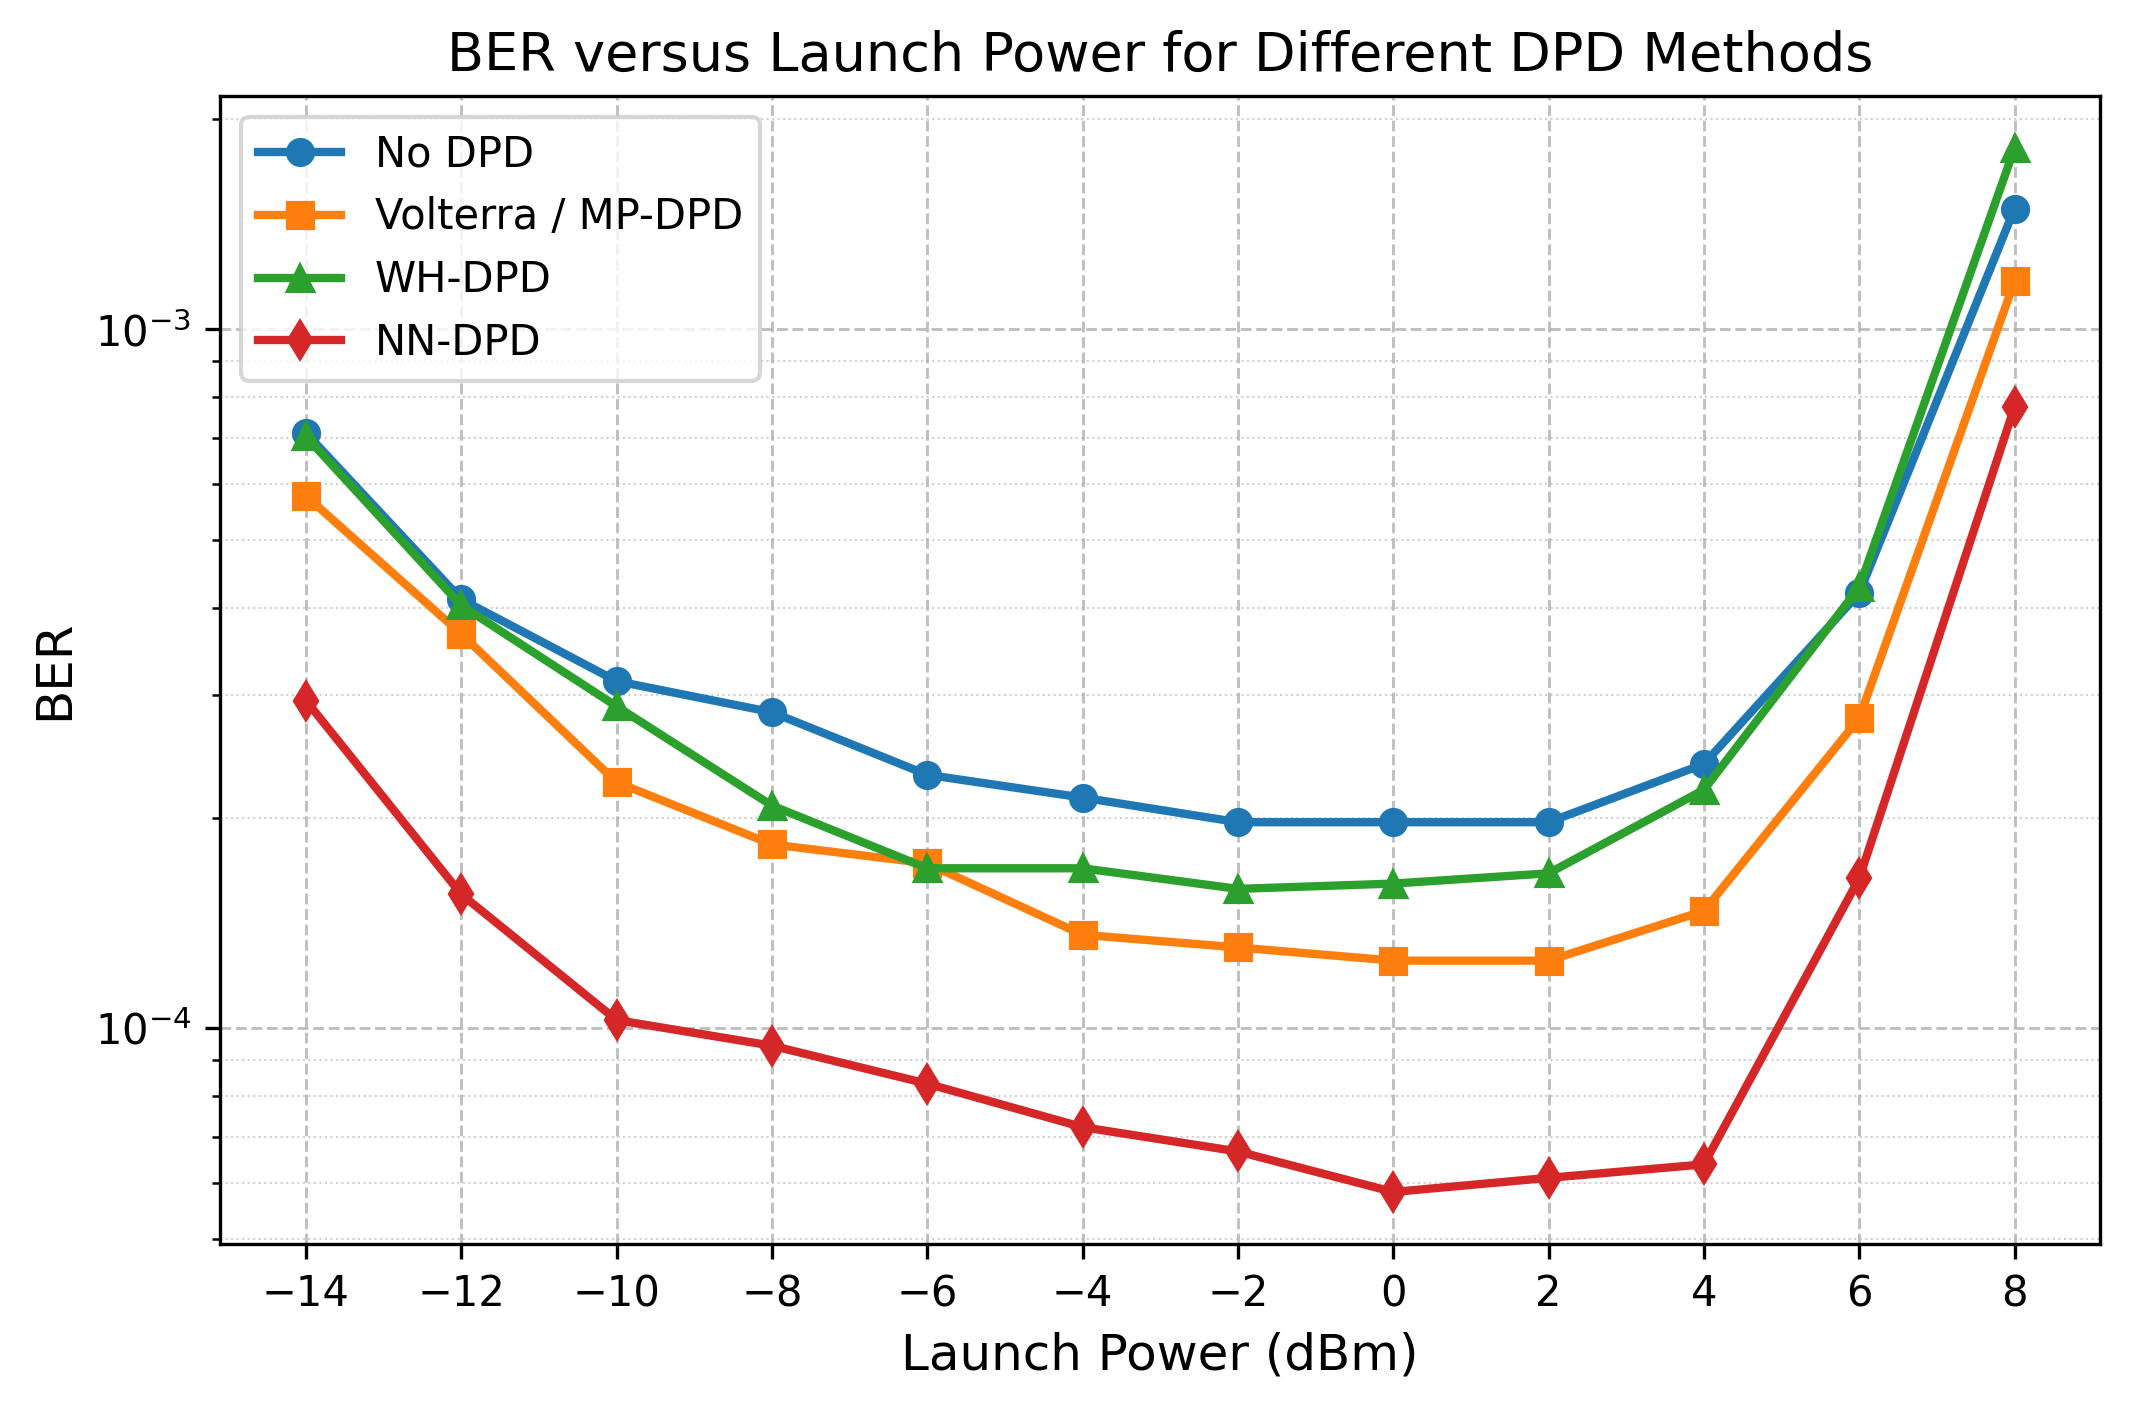

Saved: dpd_comparison_plot.png
Saved: dpd_comparison_plot.pdf


In [20]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================
mp_csv = "/home/leovo/27022026_major_project/ber_volterra_mp_results.csv"
wh_csv = "/home/leovo/27022026_major_project/ber_whdpd_results.csv"
nn_csv = "/home/leovo/27022026_major_project/major_proj/Experiementation/ber_nn_vs_nodpd.csv"

# =========================
# Read MP / Volterra CSV
# This one also provides baseline
# =========================
launch_powers = []
ber_base = []
ber_mp = []

with open(mp_csv, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        launch_powers.append(float(row["P_launch_dBm"]))
        ber_base.append(float(row["BER_No_DPD"]))
        ber_mp.append(float(row["BER_MP_DPD"]))

# =========================
# Read WH CSV
# =========================
launch_powers_wh = []
ber_wh = []

with open(wh_csv, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        launch_powers_wh.append(float(row["P_launch_dBm"]))
        ber_wh.append(float(row["BER_WHDPD"]))

# =========================
# Read NN CSV
# =========================
launch_powers_nn = []
ber_nn = []

with open(nn_csv, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        launch_powers_nn.append(float(row["P_launch_dBm"]))
        ber_nn.append(float(row["BER_NN_DPD"]))

# =========================
# Convert to numpy arrays
# =========================
launch_powers = np.array(launch_powers)
ber_base = np.array(ber_base)
ber_mp = np.array(ber_mp)

launch_powers_wh = np.array(launch_powers_wh)
ber_wh = np.array(ber_wh)

launch_powers_nn = np.array(launch_powers_nn)
ber_nn = np.array(ber_nn)

# =========================
# Optional safety checks
# =========================
if not np.array_equal(launch_powers, launch_powers_wh):
    print("Warning: WH launch powers do not match MP launch powers")

if not np.array_equal(launch_powers, launch_powers_nn):
    print("Warning: NN launch powers do not match MP launch powers")

# =========================
# Plot
# =========================
plt.figure(figsize=(7.2, 4.8), dpi=300)

plt.semilogy(launch_powers, ber_base, marker='o', linewidth=2, markersize=6, label='No DPD')
plt.semilogy(launch_powers, ber_mp, marker='s', linewidth=2, markersize=6, label='Volterra / MP-DPD')
plt.semilogy(launch_powers_wh, ber_wh, marker='^', linewidth=2, markersize=6, label='WH-DPD')
plt.semilogy(launch_powers_nn, ber_nn, marker='d', linewidth=2, markersize=6, label='NN-DPD')

plt.xlabel("Launch Power (dBm)", fontsize=12)
plt.ylabel("BER", fontsize=12)
plt.title("BER versus Launch Power for Different DPD Methods", fontsize=13)

plt.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.8)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.6)

plt.xticks(launch_powers, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, frameon=True)
plt.tight_layout()

# Save high-quality outputs
plt.savefig("dpd_comparison_plot.png", dpi=600, bbox_inches="tight")
plt.savefig("dpd_comparison_plot.pdf", bbox_inches="tight")

plt.show()

print("Saved: dpd_comparison_plot.png")
print("Saved: dpd_comparison_plot.pdf")